<a href="https://colab.research.google.com/github/AaronYounger/Quantitative-Finance/blob/main/Geometric_brownian_motion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Import Packages

import numpy as np
import math
import matplotlib.pyplot as plt

[300, 304.6941596173974, 302.88513935302797, 297.67920138215055, 298.8404235227963, 295.62226953649787, 293.0614150770348, 298.35770068854447, 299.0982666235149, 304.0234846094787, 302.16896967311044, 302.94425231860185, 307.1366855360923, 305.16505678534315, 308.58054910594797, 314.18468396496706, 311.19152815422103, 313.0170386602553, 312.74361403000904, 314.5631951275789, 311.413072450483, 317.8070691779695, 314.9078340011856, 315.38523304594287, 317.6794795766972, 335.74795958921084, 336.05600032052064, 337.4298114576873, 333.9626898287196, 332.8666637526446, 328.3876948772265, 327.2109225296017, 324.3960393931462, 323.6835146593829, 329.0500805163813, 328.17597847431915, 324.679454690732, 325.6479206832472, 321.47843499270004, 319.013255772651, 325.2028656223199, 324.45824642891114, 320.0153419190732, 323.6156794796596, 316.9374644949653, 310.08074520596654, 307.2368975476061, 312.1109400325689, 304.680137315856, 314.2694838759182, 309.8598411367888, 305.4730179660753, 311.4086573

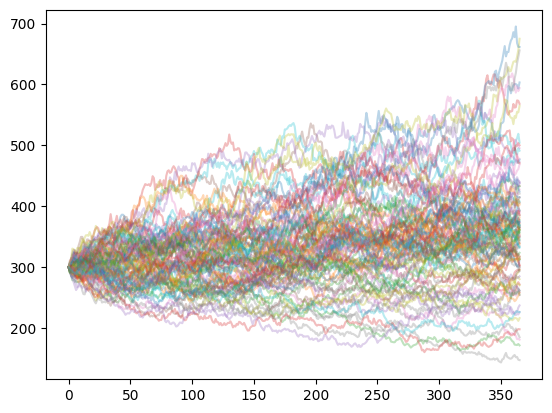

In [7]:
# Create Class Stochastic Process

## Formula for Geometric Brown Motion: 𝑑S/S = udt + odW

class StochasticProcess:

  def time_step(self):
    dW = np.random.normal(0, math.sqrt(self.delta_t))
    dS = self.drift*self.delta_t*self.current_asset_price + self.volatility*self.current_asset_price*dW
    self.asset_prices.append(self.current_asset_price + dS)
    self.current_asset_price = self.current_asset_price + dS

  def __init__(self, drift, volatility, delta_t, initial_asset_price):
    self.drift = drift
    self.volatility = volatility
    self.delta_t = delta_t
    self.current_asset_price = initial_asset_price
    self.asset_prices = [initial_asset_price]


processes = []

for i in range(0, 100):
  processes.append(StochasticProcess(0.2, 0.3, 1/365, 300))

for process in processes:
  tte = 1
  while((tte - process.delta_t) > 0):
    process.time_step()
    tte = tte - process.delta_t

for process in processes:
    plt.plot(process.asset_prices, alpha=0.3)

plt.show()


Recap:
 Built a Monte Carlo simulation of geometric Brownian motion using Euler discretization to generate multiple possible future asset price paths driven by drift and stochastic volatility.


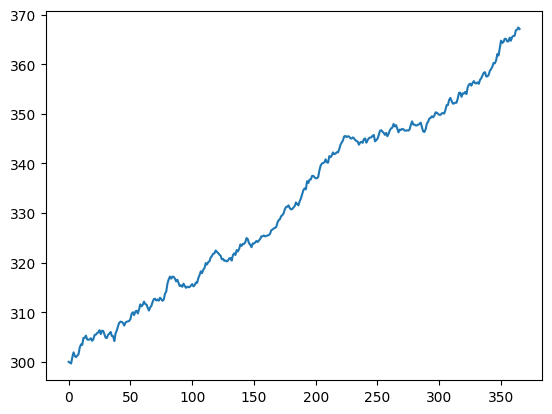

In [9]:
# Compute the Average Path
all_paths = np.array([process.asset_prices for process in processes])
average_path = np.mean(all_paths, axis=0)

plt.plot(average_path)
plt.show()
